# OCR 

## Import


In [8]:
# import 
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
import struct
from pathlib import Path
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')


## data import


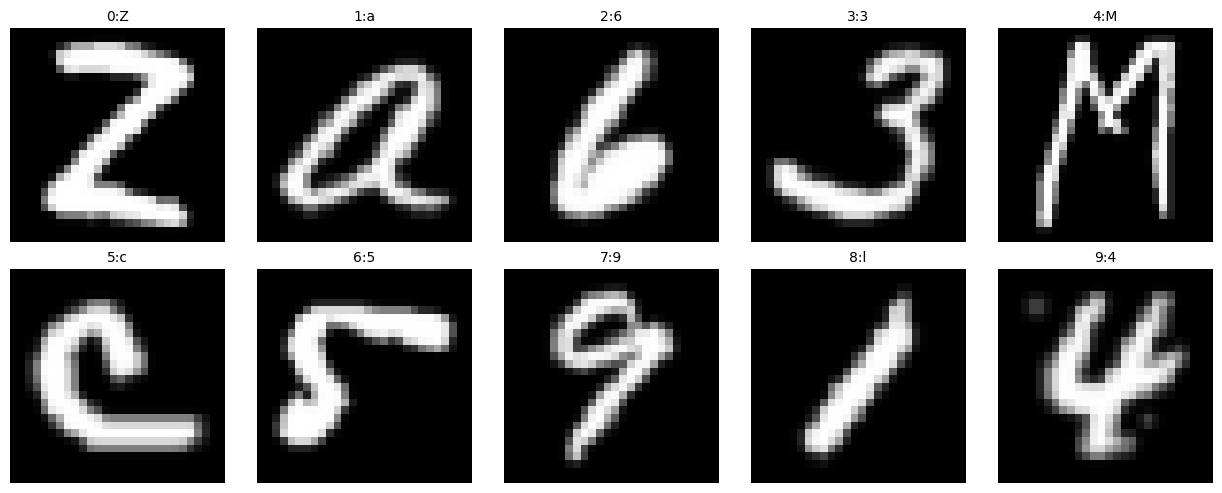

In [7]:
# construction du set d'image 
DATA_DIR = Path("../student_dataset/image_data").resolve()


class MyDataset(Dataset):
    def __init__(self, images_path, labels_path, mapping_path=None):
        images_path = Path(images_path)
        labels_path = Path(labels_path)
        mapping_path = Path(mapping_path) if mapping_path is not None else DATA_DIR / "mapping.txt"

        # Load images
        with open(images_path, "rb") as f:
            magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
            images = np.frombuffer(f.read(), dtype=np.uint8)
            images = images.reshape(num, rows, cols)

        # Load labels
        with open(labels_path, "rb") as f:
            magic, num = struct.unpack(">II", f.read(8))
            labels = np.frombuffer(f.read(), dtype=np.uint8)

        # Load mapping from label index -> ASCII code -> character
        self.mapping = {}
        try:
            with open(mapping_path, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith("#"):
                        continue
                    idx_str, ascii_str = line.split(" ")
                    idx = int(idx_str)
                    ascii_val = int(ascii_str)
                    self.mapping[idx] = chr(ascii_val)
        except FileNotFoundError:
            raise FileNotFoundError(f"Mapping file not found: {mapping_path}")

        # Fix orientation (rotated)
        images = np.transpose(images, (0, 2, 1)).copy()

        # Convert to PyTorch tensors
        self.images = torch.tensor(images, dtype=torch.float32) / 255.0
        self.labels = torch.tensor(labels, dtype=torch.long)
        # Convert to character labels from mapping
        if not self.mapping:
            raise ValueError("Empty mapping, cannot map label indices to characters")
        self.char_labels = [self.mapping[int(l)] for l in labels]
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx].unsqueeze(0), self.char_labels[idx]

    def show_sample(self, idx=0, count=1):
        if count == 1:
            img, lbl = self[idx]
            img_np = img.squeeze(0).numpy()
            plt.figure(figsize=(4,4))
            plt.imshow(img_np, cmap='gray')
            plt.title(f"Label: {lbl}")
            plt.axis('off')
            plt.show()
            return

        count = min(count, len(self)-idx)
        cols = min(5, count)
        rows = (count + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
        axes = np.array(axes).reshape(-1)

        for i in range(count):
            img, lbl = self[idx + i]
            img_np = img.squeeze(0).numpy()
            ax = axes[i]
            ax.imshow(img_np, cmap='gray')
            ax.set_title(f"{idx+i}:{lbl}", fontsize=10)
            ax.axis('off')

        for i in range(count, len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()


# Paths to your files
images_file = DATA_DIR / "train-images-idx3-ubyte"
labels_file = DATA_DIR / "train-labels-idx1-ubyte"

# Create dataset
dataset = MyDataset(images_file, labels_file)

# Show 10 samples starting at index 0
dataset.show_sample(idx=0, count=10)

## preprocessing des data

Train: (628138, 28, 28, 1) | Val: (69794, 28, 28, 1) | Test: (116323, 28, 28, 1)
Nombre de classes: 62
Exemples de labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


Model: "ocr_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,150 (973.24 KB)

 Trainable params: 248,702 (971.49 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 146s 59ms/step - accuracy: 0.7816 - loss: 0.6882 - val_accuracy: 0.8388 - val_loss: 0.4381
Epoch 2/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 142s 58ms/step - accuracy: 0.8327 - loss: 0.4801 - val_accuracy: 0.8392 - val_loss: 0.4347
Epoch 3/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 139s 57ms/step - accuracy: 0.8400 - loss: 0.4517 - val_accuracy: 0.8404 - val_loss: 0.4251
Epoch 4/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 134s 55ms/step - accuracy: 0.8442 - loss: 0.4365 - val_accuracy: 0.8383 - val_loss: 0.4352
Epoch 5/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 136s 55ms/step - accuracy: 0.8476 - loss: 0.4250 - val_accuracy: 0.8547 - val_loss: 0.3858
Epoch 6/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 139s 57ms/step - accuracy: 0.8501 - loss: 0.4155 - val_accuracy: 0.8428 - val_loss: 0.4097
Epoch 7/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 144s 59ms/step - accuracy: 0.8518 - loss: 0.4091 - val_accuracy: 0.8549 - val_loss: 0.3835
Epoch 8/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 139s 57ms/step - accuracy: 

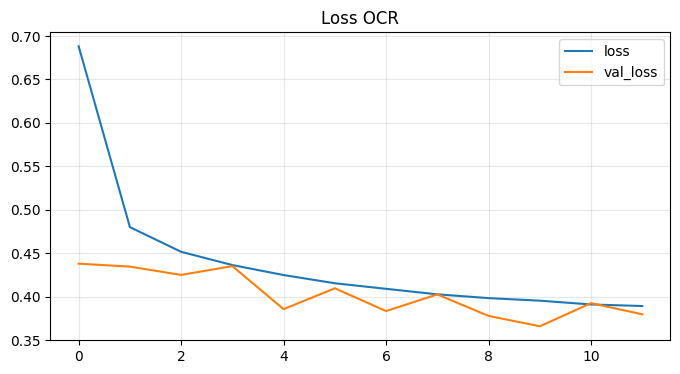

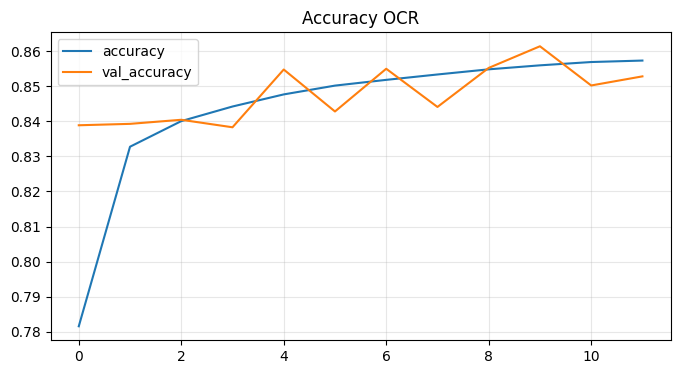

Test loss: 0.3614
Test accuracy: 86.3810%
              precision    recall  f1-score   support

           0       0.64      0.89      0.75      5778
           1       0.62      0.95      0.75      6330
           2       0.97      0.96      0.97      5869
           3       0.99      0.99      0.99      5969
           4       0.97      0.98      0.97      5619
           5       0.96      0.94      0.95      5190
           6       0.97      0.98      0.98      5705
           7       0.99      0.99      0.99      6139
           8       0.98      0.99      0.99      5633
           9       0.93      0.98      0.95      5686
           A       0.97      0.98      0.97      1062
           B       0.92      0.98      0.95       648
           C       0.78      0.95      0.86      1739
           D       0.81      0.95      0.88       779
           E       0.96      0.98      0.97       851
           F       0.77      0.97      0.86      1440
           G       0.91      0.91      

,reel,predit,n
307,O,0,2506
572,l,1,2040
246,I,1,1411
589,m,M,458
703,u,U,437
457,c,C,417
10,0,O,417
672,s,S,393
502,f,F,361
612,o,0,306


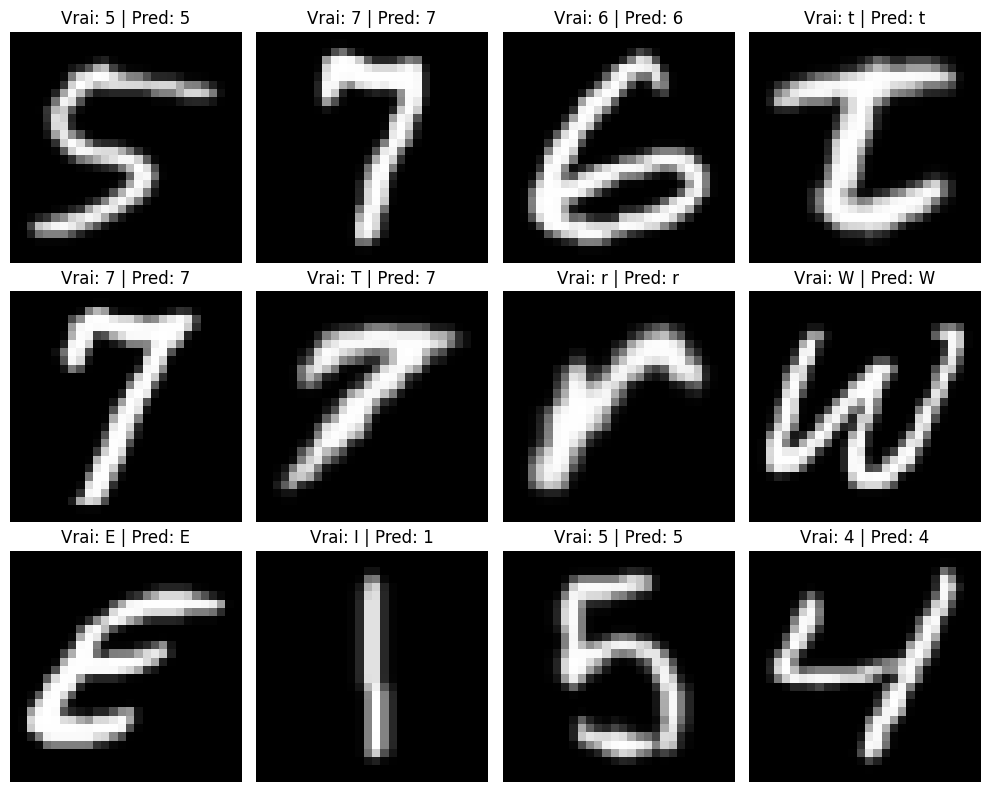

In [9]:


test_images_file = DATA_DIR / "test-images-idx3-ubyte"
test_labels_file = DATA_DIR / "test-labels-idx1-ubyte"

test_dataset = MyDataset(test_images_file, test_labels_file)

class_names = [dataset.mapping[i] for i in sorted(dataset.mapping)]
num_classes = len(class_names)

X_train_full = dataset.images.numpy()[..., np.newaxis]
y_train_full = dataset.labels.numpy().astype("int32")
X_test = test_dataset.images.numpy()[..., np.newaxis]
y_test = test_dataset.labels.numpy().astype("int32")

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1,
    random_state=0,
    stratify=y_train_full,
)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Nombre de classes: {num_classes}")
print(f"Exemples de labels: {class_names[:10]}")

batch_size = 256
autotune = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(20000, seed=0).batch(batch_size).prefetch(autotune)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(batch_size).prefetch(autotune)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(batch_size).prefetch(autotune)

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.08, 0.08),
], name="augmentation")

def build_ocr_model(input_shape=(28, 28, 1), num_classes=num_classes):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="ocr_cnn")

model = build_ocr_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[early_stopping],
    verbose=1,
)

history_df = pd.DataFrame(history.history)
history_df[["loss", "val_loss"]].plot(figsize=(8, 4), title="Loss OCR")
plt.grid(alpha=0.3)
plt.show()

history_df[["accuracy", "val_accuracy"]].plot(figsize=(8, 4), title="Accuracy OCR")
plt.grid(alpha=0.3)
plt.show()

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4%}")

y_proba = model.predict(test_ds, verbose=0)
y_pred = y_proba.argmax(axis=1)

report = classification_report(
    y_test,
    y_pred,
    labels=np.arange(num_classes),
    target_names=class_names,
    zero_division=0,
)
print(report)

cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))
confusions = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confusions.append((class_names[i], class_names[j], int(cm[i, j])))

top_confusions = pd.DataFrame(confusions, columns=["reel", "predit", "n"]).sort_values("n", ascending=False).head(15)
display(top_confusions)

sample_idx = np.random.default_rng(0).choice(len(X_test), size=12, replace=False)
sample_images = X_test[sample_idx]
sample_preds = model.predict(sample_images, verbose=0).argmax(axis=1)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for ax, image, true_idx, pred_idx in zip(axes.ravel(), sample_images, y_test[sample_idx], sample_preds):
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Vrai: {class_names[true_idx]} | Pred: {class_names[pred_idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()
